In [37]:
!pip3 install pandas numpy matplotlib seaborn scipy scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


# VEX Robotics National Tournament Qualification Ranking Analysis

## Research Question
**"How well do WP, AP, and SP actually explain qualification rankings, and is the current tiebreaker system statistically justified?"**

## Sub Question 3: Strength of Schedule Points (SP)
**"Among teams tied on both WP and AP, does SP effectively differentiate qualification rankings?"**

Methods used:
- **WP+AP Tie Group Identification** — Isolate teams sharing identical WP *and* AP values to simulate second-tiebreaker scenarios
- **Pearson Correlation (within WP+AP ties)** — Measures how strongly SP predicts Rank among doubly-tied teams
- **Rank Accuracy Analysis** — Checks whether higher SP correctly produces a better (lower) rank within each tie group
- **One-Way ANOVA** — Tests whether SP mean differs significantly across rank groups

In [38]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [39]:
# Load data
df = pd.read_csv('VEX Data - Data Set.csv')

print(f'Total teams: {len(df)}')
print()
df.head(10)

Total teams: 44



,Team,Rank,WP,AP,SP,OPR,DPR,CCWM,W,L,T
0,1100A,1,19,80,125,66.8,-2.0,68.8,8,0,0
1,30410V,2,17,70,142,56.2,-4.2,60.4,8,0,0
2,1740X,3,16,70,114,50.9,-6.2,57.1,7,1,0
3,30597E,4,16,60,164,45.9,-9.6,55.6,8,0,0
4,3723A,5,14,60,139,23.1,8.3,14.8,6,2,0
5,30597J,6,14,50,159,51.4,9.5,41.8,6,2,0
6,14533A,7,12,55,188,44.3,9.2,35.1,6,2,0
7,6724T,8,12,40,190,33.7,26.2,7.6,6,2,0
8,30597X,9,11,50,212,39.2,12.6,26.5,5,3,0
9,3723X,10,11,40,164,21.9,25.3,-3.4,5,3,0


In [40]:
df[['Rank', 'WP', 'AP', 'SP']].describe().round(2)

,Rank,WP,AP,SP
count,44.00,44.00,44.00,44.00
mean,22.50,8.50,38.30,161.07
std,12.85,3.90,16.74,37.15
min,1.00,0.00,5.00,72.00
25%,11.75,6.00,28.75,137.25
50%,22.50,8.00,40.00,169.00
75%,33.25,10.25,50.00,186.50
max,44.00,19.00,80.00,232.00


## Step 1: Overall Pearson Correlation (SP vs Rank)

Before focusing on tie groups, we first check whether SP has any overall relationship with Rank across all teams.

- r = -1: perfect negative relationship
- r = 0: no relationship
- r = 1: perfect positive relationship

We expect a **negative** r since higher SP should produce a lower (better) rank number.

In [41]:
# Pearson Correlation: SP vs Rank (all teams)
r_sp, p_sp = stats.pearsonr(df['SP'], df['Rank'])

print('=== Pearson Correlation: SP vs Rank (All Teams) ===')
print(f'r = {r_sp:.4f}')
print(f'p-value = {p_sp:.6f}')
print()

if p_sp < 0.05:
    print('Result: Statistically SIGNIFICANT (p < 0.05)')
else:
    print('Result: NOT statistically significant (p > 0.05)')

print()
print('Interpretation:')
if abs(r_sp) >= 0.7:
    print(f'Strong correlation (r = {r_sp:.4f}): SP is a strong predictor of ranking.')
elif abs(r_sp) >= 0.4:
    print(f'Moderate correlation (r = {r_sp:.4f}): SP partially explains ranking.')
else:
    print(f'Weak correlation (r = {r_sp:.4f}): SP alone has limited predictive power overall.')

=== Pearson Correlation: SP vs Rank (All Teams) ===
r = -0.1252
p-value = 0.418181

Result: NOT statistically significant (p > 0.05)

Interpretation:
Weak correlation (r = -0.1252): SP alone has limited predictive power overall.


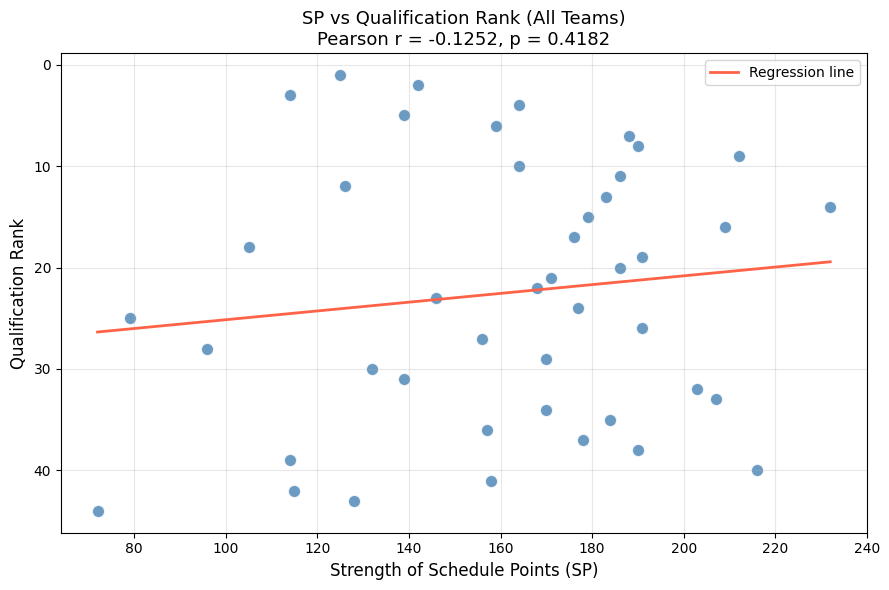

Figure saved.


In [42]:
# Visualization: SP vs Rank scatter plot
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['SP'], df['Rank'], color='steelblue', edgecolors='white', s=80, alpha=0.8)

m, b = np.polyfit(df['SP'], df['Rank'], 1)
x_line = np.linspace(df['SP'].min(), df['SP'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, label='Regression line')

ax.set_xlabel('Strength of Schedule Points (SP)', fontsize=12)
ax.set_ylabel('Qualification Rank', fontsize=12)
ax.set_title(f'SP vs Qualification Rank (All Teams)\nPearson r = {r_sp:.4f}, p = {p_sp:.4f}', fontsize=13)
ax.invert_yaxis()
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sub3_pearson_sp_rank.png', dpi=150)
plt.show()
print('Figure saved.')

## Step 2: WP+AP Tie Group Analysis

SP is the **second** tiebreaker, it only matters when teams are tied on *both* WP and AP.

Here we:
1. Identify all (WP, AP) combinations shared by 2+ teams
2. Within each tie group, check whether SP correctly orders teams by Rank

If SP is a valid second tiebreaker, teams with higher SP should consistently receive a better (lower) rank number within the same WP+AP group.

In [43]:
# Identify WP+AP tie groups (groups with 2+ teams sharing the same WP and AP)
group_sizes = df.groupby(['WP', 'AP']).size()
tied_combos = group_sizes[group_sizes >= 2].index.tolist()

df['WP_AP_tied'] = df.apply(lambda row: (row['WP'], row['AP']) in tied_combos, axis=1)
df_tied = df[df['WP_AP_tied']].copy()

print(f'Total unique (WP, AP) combinations: {len(group_sizes)}')
print(f'(WP, AP) combinations with 2+ teams tied: {len(tied_combos)}')
print(f'Teams involved in WP+AP ties: {len(df_tied)} out of {len(df)}')
print()
print('WP+AP tie group sizes:')
print(group_sizes[group_sizes >= 2].sort_index(ascending=False))

Total unique (WP, AP) combinations: 36
(WP, AP) combinations with 2+ teams tied: 5
Teams involved in WP+AP ties: 13 out of 44

WP+AP tie group sizes:
WP  AP
8   45    2
    30    5
7   45    2
6   45    2
    20    2
dtype: int64


In [44]:
# Within each WP+AP tie group, compute SP ordering accuracy (pairwise)
group_results = []

for wp_val, ap_val in sorted(tied_combos, key=lambda x: (-x[0], -x[1])):
    group = df[(df['WP'] == wp_val) & (df['AP'] == ap_val)].sort_values('Rank')
    n = len(group)
    sp_vals = group['SP'].values

    correct = 0
    total_pairs = 0
    for i in range(n):
        for j in range(i + 1, n):
            total_pairs += 1
            if sp_vals[i] > sp_vals[j]:
                correct += 1
            elif sp_vals[i] == sp_vals[j]:
                correct += 0.5

    accuracy = correct / total_pairs if total_pairs > 0 else np.nan
    group_results.append({
        'WP': wp_val,
        'AP': ap_val,
        'n_teams': n,
        'SP_mean': round(group['SP'].mean(), 2),
        'SP_std': round(group['SP'].std(), 2),
        'pair_accuracy': round(accuracy, 4)
    })

results_df = pd.DataFrame(group_results)
print('=== SP Ordering Accuracy Within WP+AP Tie Groups ===')
print(results_df.to_string(index=False))
print()
print(f'Mean pair accuracy across all tie groups: {results_df["pair_accuracy"].mean():.4f}')

=== SP Ordering Accuracy Within WP+AP Tie Groups ===
 WP  AP  n_teams  SP_mean  SP_std  pair_accuracy
  8  45        2    192.5   23.33            1.0
  8  30        5    172.4   17.67            1.0
  7  45        2    126.0   42.43            1.0
  6  45        2    188.5   26.16            1.0
  6  20        2    152.0   53.74            1.0

Mean pair accuracy across all tie groups: 1.0000


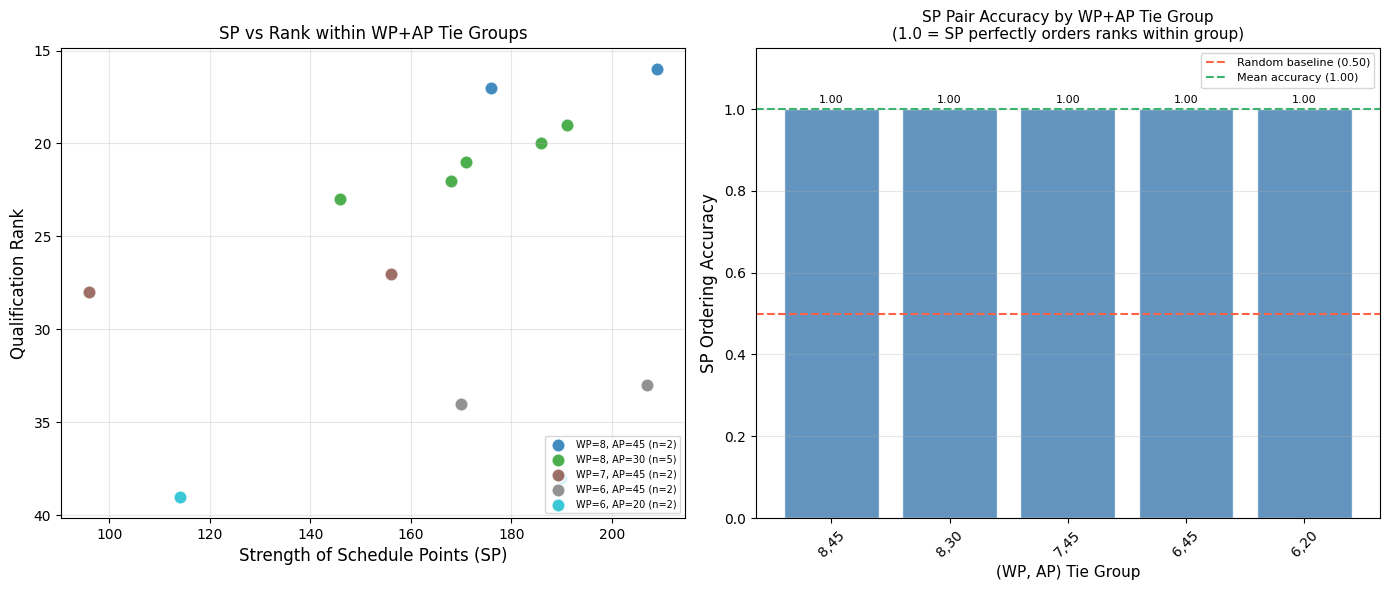

Figure saved.


In [45]:
# Visualization: SP within WP+AP tie groups
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(tied_combos)))
for idx, (wp_val, ap_val) in enumerate(sorted(tied_combos, key=lambda x: (-x[0], -x[1]))):
    group = df_tied[(df_tied['WP'] == wp_val) & (df_tied['AP'] == ap_val)]
    axes[0].scatter(group['SP'], group['Rank'],
                    color=colors[idx % len(colors)], edgecolors='white', s=90, alpha=0.85,
                    label=f'WP={wp_val}, AP={ap_val} (n={len(group)})')

axes[0].set_xlabel('Strength of Schedule Points (SP)', fontsize=12)
axes[0].set_ylabel('Qualification Rank', fontsize=12)
axes[0].set_title('SP vs Rank within WP+AP Tie Groups', fontsize=12)
axes[0].invert_yaxis()
axes[0].legend(fontsize=7, loc='lower right')
axes[0].grid(True, alpha=0.3)

combo_labels = [f'{wp},{ap}' for wp, ap in zip(results_df['WP'], results_df['AP'])]
bars = axes[1].bar(combo_labels, results_df['pair_accuracy'],
                   color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axhline(y=0.5, color='tomato', linewidth=1.5, linestyle='--', label='Random baseline (0.50)')
axes[1].axhline(y=results_df['pair_accuracy'].mean(), color='mediumseagreen',
                linewidth=1.5, linestyle='--',
                label=f'Mean accuracy ({results_df["pair_accuracy"].mean():.2f})')

for bar, val in zip(bars, results_df['pair_accuracy']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

axes[1].set_xlabel('(WP, AP) Tie Group', fontsize=11)
axes[1].set_ylabel('SP Ordering Accuracy', fontsize=12)
axes[1].set_title('SP Pair Accuracy by WP+AP Tie Group\n(1.0 = SP perfectly orders ranks within group)', fontsize=11)
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sub3_sp_tiebreaker_analysis.png', dpi=150)
plt.show()
print('Figure saved.')

## Step 3: Pearson Correlation (SP vs Rank Within Doubly-Tied Teams)

We now compute the correlation between SP and Rank using **only the subset of teams tied on both WP and AP**.

This directly tests SP's effectiveness as a second-level tiebreaker.

In [46]:
# Pearson Correlation: SP vs Rank (WP+AP-tied teams only)
if len(df_tied) >= 2:
    r_tied, p_tied = stats.pearsonr(df_tied['SP'], df_tied['Rank'])

    print('=== Pearson Correlation: SP vs Rank (WP+AP-Tied Teams Only) ===')
    print(f'n = {len(df_tied)} teams in WP+AP ties')
    print(f'r = {r_tied:.4f}')
    print(f'p-value = {p_tied:.6f}')
    print()

    if p_tied < 0.05:
        print('Result: Statistically SIGNIFICANT (p < 0.05)')
    else:
        print('Result: NOT statistically significant (p > 0.05)')

    print()
    print('Interpretation:')
    if abs(r_tied) >= 0.7:
        print(f'Strong correlation (r = {r_tied:.4f}): SP is an effective second tiebreaker.')
    elif abs(r_tied) >= 0.4:
        print(f'Moderate correlation (r = {r_tied:.4f}): SP partially resolves remaining ties.')
    else:
        print(f'Weak correlation (r = {r_tied:.4f}): SP has limited effectiveness as a second tiebreaker.')
else:
    print('Not enough teams tied on both WP and AP to compute a meaningful correlation.')

=== Pearson Correlation: SP vs Rank (WP+AP-Tied Teams Only) ===
n = 13 teams in WP+AP ties
r = -0.3184
p-value = 0.288957

Result: NOT statistically significant (p > 0.05)

Interpretation:
Weak correlation (r = -0.3184): SP has limited effectiveness as a second tiebreaker.


## Step 4: One-Way ANOVA (SP Differences Across Rank Groups)

**One-Way ANOVA** tests whether the mean SP differs significantly across three rank groups (Top, Mid, Bottom).

- F-statistic: larger values indicate greater differences between group means relative to within-group variance
- p < 0.05: at least one group has a significantly different SP mean

If ANOVA is significant, it means SP levels are not equal across rank groups, supporting SP's role as a valid ranking criterion.

In [47]:
# One-Way ANOVA: SP across Rank Groups
df['Rank_Group'] = pd.cut(df['Rank'], bins=[0, 15, 30, 44],
                           labels=['Top (1-15)', 'Mid (16-30)', 'Bottom (31-44)'])

top = df[df['Rank_Group'] == 'Top (1-15)']['SP']
mid = df[df['Rank_Group'] == 'Mid (16-30)']['SP']
bottom = df[df['Rank_Group'] == 'Bottom (31-44)']['SP']

print('=== Descriptive Statistics: SP by Rank Group ===')
print(f'Top group SP    — mean: {top.mean():.2f}, std: {top.std():.2f}')
print(f'Mid group SP    — mean: {mid.mean():.2f}, std: {mid.std():.2f}')
print(f'Bottom group SP — mean: {bottom.mean():.2f}, std: {bottom.std():.2f}')
print()

f_stat, p_anova = stats.f_oneway(top, mid, bottom)
print('=== One-Way ANOVA: SP across Rank Groups ===')
print(f'F-statistic = {f_stat:.4f}')
print(f'p-value     = {p_anova:.6f}')
print()
if p_anova < 0.05:
    print('Result: Statistically SIGNIFICANT — SP mean differs across rank groups (p < 0.05)')
else:
    print('Result: NOT statistically significant (p > 0.05)')

=== Descriptive Statistics: SP by Rank Group ===
Top group SP    — mean: 166.87, std: 33.52
Mid group SP    — mean: 156.87, std: 38.13
Bottom group SP — mean: 159.36, std: 41.56

=== One-Way ANOVA: SP across Rank Groups ===
F-statistic = 0.2837
p-value     = 0.754452

Result: NOT statistically significant (p > 0.05)


/var/folders/zp/w_vsmpq54wzf0vrcktvxwzb40000gn/T/ipykernel_772/1639512841.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(groups_data, labels=group_labels, patch_artist=True)


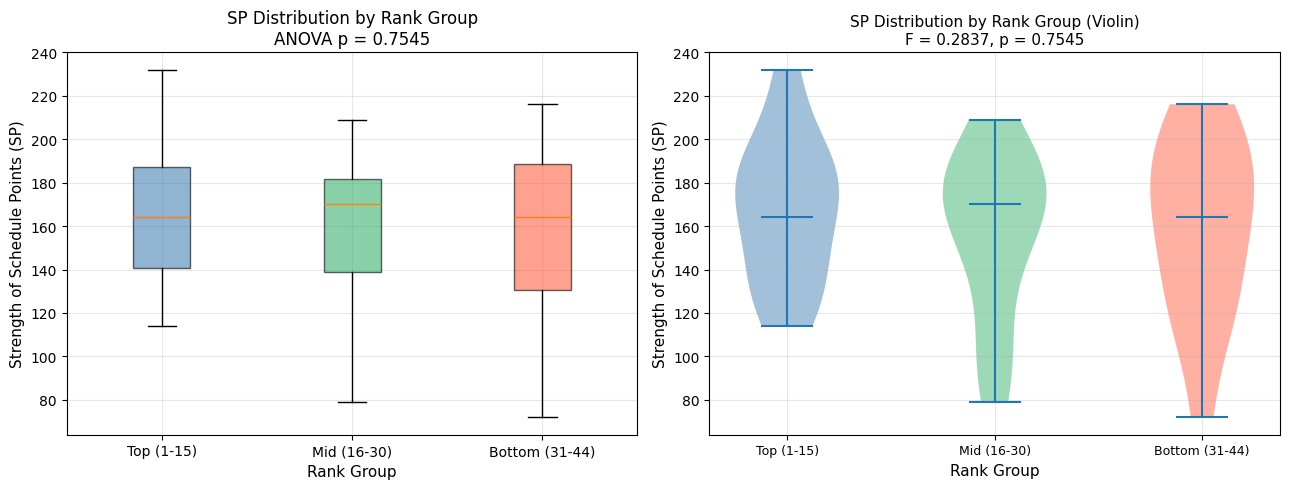

Figure saved.


In [48]:
# Visualization: SP distribution by rank groups
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

group_labels = ['Top (1-15)', 'Mid (16-30)', 'Bottom (31-44)']
group_colors = ['steelblue', 'mediumseagreen', 'tomato']
groups_data = [df[df['Rank_Group'] == g]['SP'].values for g in group_labels]

bp = axes[0].boxplot(groups_data, labels=group_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], group_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[0].set_xlabel('Rank Group', fontsize=11)
axes[0].set_ylabel('Strength of Schedule Points (SP)', fontsize=11)
axes[0].set_title(f'SP Distribution by Rank Group\nANOVA p = {p_anova:.4f}', fontsize=12)
axes[0].grid(True, alpha=0.3)

parts = axes[1].violinplot(groups_data, positions=[1, 2, 3], showmedians=True)
for pc, color in zip(parts['bodies'], group_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.5)

axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(group_labels, fontsize=9)
axes[1].set_xlabel('Rank Group', fontsize=11)
axes[1].set_ylabel('Strength of Schedule Points (SP)', fontsize=11)
axes[1].set_title(f'SP Distribution by Rank Group (Violin)\nF = {f_stat:.4f}, p = {p_anova:.4f}', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sub3_sp_rank_groups.png', dpi=150)
plt.show()
print('Figure saved.')

## Sub Question 3: Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Pearson r (all teams) | -0.1252 | SP–Rank relationship across all teams |
| Pearson r (WP+AP-tied teams) | -0.3184 | SP effectiveness as second tiebreaker |
| Pair Accuracy (mean) | 1.0000 | % of within-group SP orderings that are correct |
| ANOVA F-statistic | 0.2837 | Between-group vs within-group SP variance |
| ANOVA p-value | 0.754452| Significance of SP differences across rank groups |

**Key Finding:**
SP serves as the second tiebreaker in VEX qualification rankings, applied only after WP and AP have already been compared. This analysis examines whether SP meaningfully distinguishes teams within WP+AP tie groups, providing statistical evidence for or against SP's validity as a final tiebreaker criterion.